# Análise Exploratória de Dados — Churn Prediction
**FIAP Tech Challenge — Fase 1**

**Dataset:** Telco Customer Churn (IBM)  
**Objetivo:** Identificar clientes com risco de cancelamento (churn)  
**Etapa:** 1 — Entendimento e Preparação

---
### Estrutura do notebook
1. Configuração do ambiente
2. Carregamento dos dados
3. Análise de volume e qualidade
4. Análise da variável alvo
5. Análise de distribuição das features
6. Análise de correlações
7. Data Readiness
8. Definição de métricas
9. Registro no MLflow
10. Conclusões e próximos passos

## 1. Configuração do ambiente

In [1]:
import warnings

warnings.filterwarnings('ignore')

import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns

# Garante que o working directory é sempre a raiz do projeto
os.chdir(Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent)
print(f'Working directory: {Path.cwd()}')
from pathlib import Path

from src.utils.config import set_global_seed, settings
from src.utils.logger import get_logger

# Seed global para reprodutibilidade
set_global_seed(settings.seed)
logger = get_logger(__name__)

# Estilo dos gráficos
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

# Caminhos
DATA_PATH = Path(settings.data_path)

logger.info(f'Seed: {settings.seed}')
logger.info(f'Dataset: {DATA_PATH}')
print('✅ Ambiente configurado com sucesso!')

Working directory: /Users/marcelo-salvador/desenvolvimento/workspace/fiap/10mlet/fase1/FIAP-MLE-Fase01
2026-05-17 11:53:20 | INFO     | __main__:<module>:32 | Seed: 42
2026-05-17 11:53:20 | INFO     | __main__:<module>:33 | Dataset: data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
✅ Ambiente configurado com sucesso!


## 2. Carregamento dos dados

In [2]:
df = pd.read_csv(DATA_PATH)

logger.info(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(f'Shape: {df.shape}')
df.head()

2026-05-17 11:53:20 | INFO     | __main__:<module>:3 | Dataset carregado: 7043 linhas x 21 colunas
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Tipos de dados
print('Tipos de dados:')
print(df.dtypes)
print(f'\nMemória utilizada: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

Tipos de dados:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Memória utilizada: 6984.7 KB


## 3. Análise de volume e qualidade

In [4]:
# ── Valores ausentes ──────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valores ausentes': missing,
    'Percentual (%)': missing_pct
}).query('`Valores ausentes` > 0')

if missing_df.empty:
    print('✅ Nenhum valor ausente encontrado!')
else:
    print('⚠️  Valores ausentes encontrados:')
    display(missing_df)

✅ Nenhum valor ausente encontrado!


In [5]:
# ── TotalCharges: possível problema de tipo ───────────────────────────────────
# O dataset Telco tem TotalCharges como string com espaços vazios
print('Tipo original de TotalCharges:', df['TotalCharges'].dtype)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

n_coerced = df['TotalCharges'].isnull().sum()
logger.info(f'TotalCharges: {n_coerced} valores convertidos para NaN')
print(f'Registros com TotalCharges inválido: {n_coerced}')

# Remove registros com TotalCharges nulo (clientes novos sem histórico)
df = df.dropna(subset=['TotalCharges'])
print(f'Shape após limpeza: {df.shape}')

Tipo original de TotalCharges: object
2026-05-17 11:53:21 | INFO     | __main__:<module>:8 | TotalCharges: 11 valores convertidos para NaN
Registros com TotalCharges inválido: 11
Shape após limpeza: (7032, 21)


In [6]:
# ── Duplicatas ────────────────────────────────────────────────────────────────
n_dupl = df.duplicated().sum()
n_dupl_id = df['customerID'].duplicated().sum()

print(f'Linhas duplicadas: {n_dupl}')
print(f'customerID duplicados: {n_dupl_id}')

if n_dupl == 0 and n_dupl_id == 0:
    print('✅ Sem duplicatas!')

Linhas duplicadas: 0
customerID duplicados: 0
✅ Sem duplicatas!


In [7]:
# ── Estatísticas descritivas ──────────────────────────────────────────────────
print('=== Variáveis numéricas ===')
display(df.describe().round(2))

print('\n=== Variáveis categóricas ===')
display(df.describe(include='object').T)

=== Variáveis numéricas ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00,7032.00
mean,0.16,32.42,64.80,2283.30
std,0.37,24.55,30.09,2266.77
min,0.00,1.00,18.25,18.80
25%,0.00,9.00,35.59,401.45
50%,0.00,29.00,70.35,1397.48
75%,0.00,55.00,89.86,3794.74
max,1.00,72.00,118.75,8684.80



=== Variáveis categóricas ===


,count,unique,top,freq
customerID,7032,7032,7590-VHVEG,1
gender,7032,2,Male,3549
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094


## 4. Análise da variável alvo (Churn)

Distribuição do Churn:
       Contagem  Percentual (%)
Churn                          
No         5163           73.42
Yes        1869           26.58


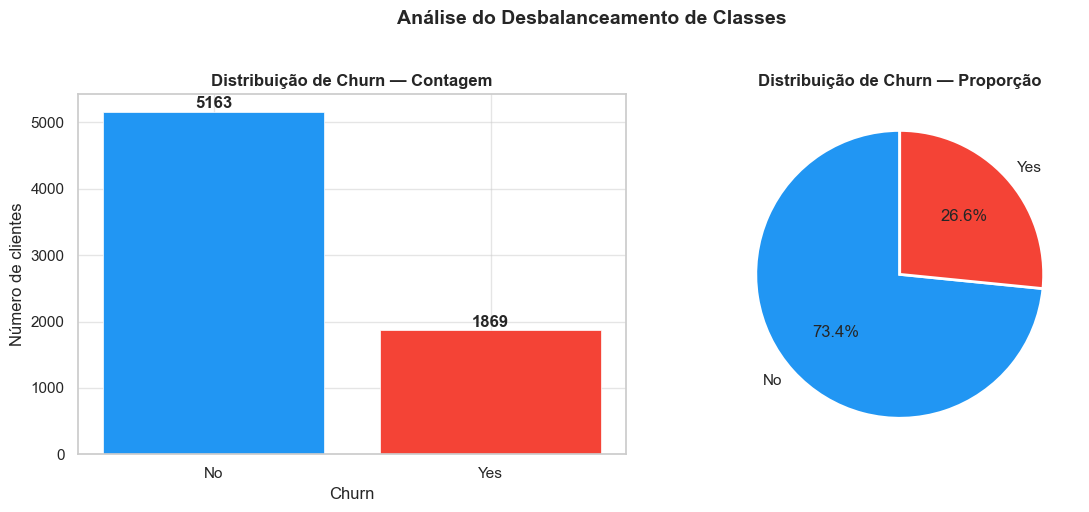

2026-05-17 11:53:21 | INFO     | __main__:<module>:31 | Taxa de churn: 26.6%

⚠️  Taxa de churn: 26.6% — dataset desbalanceado!
→ Estratégia: SMOTE + class_weight no PyTorch + métricas PR-AUC e F1


In [8]:
# ── Distribuição do target ────────────────────────────────────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Distribuição do Churn:')
print(pd.DataFrame({'Contagem': churn_counts, 'Percentual (%)': churn_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribuição de Churn — Contagem', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Número de clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Gráfico de pizza
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Distribuição de Churn — Proporção', fontweight='bold')

plt.suptitle('Análise do Desbalanceamento de Classes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('docs/eda_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

churn_rate = churn_pct['Yes']
logger.info(f'Taxa de churn: {churn_rate:.1f}%')
print(f'\n⚠️  Taxa de churn: {churn_rate:.1f}% — dataset desbalanceado!')
print('→ Estratégia: SMOTE + class_weight no PyTorch + métricas PR-AUC e F1')

## 5. Análise de distribuição das features

In [9]:
# ── Separação de features por tipo ───────────────────────────────────────────
# Remove colunas não preditivas
cols_drop = ['customerID']

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = [c for c in df.select_dtypes(include='object').columns
            if c not in cols_drop + ['Churn']]

print(f'Features numéricas ({len(num_cols)}): {num_cols}')
print(f'Features categóricas ({len(cat_cols)}): {cat_cols}')

Features numéricas (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Features categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


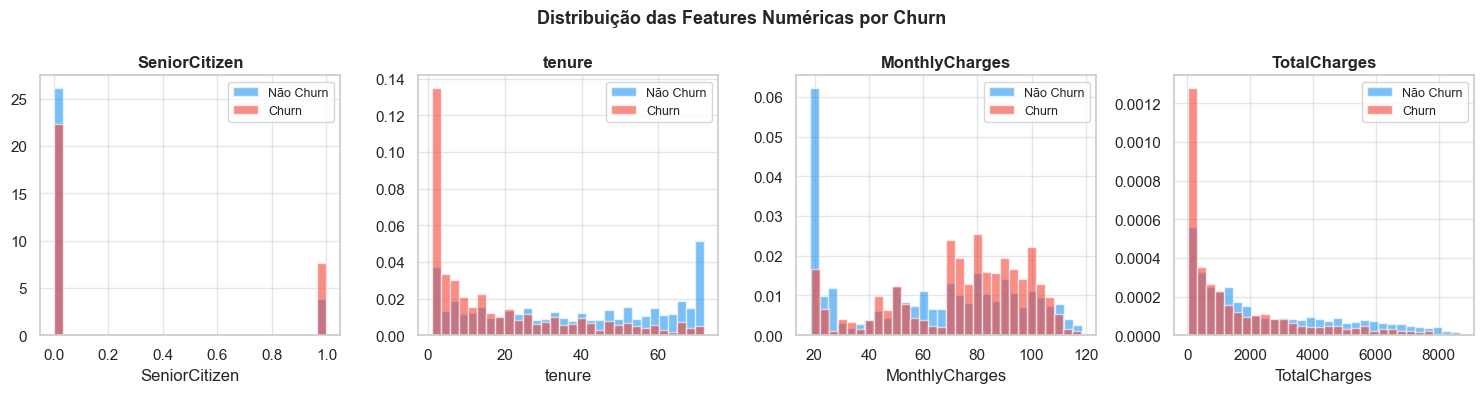

In [10]:
# ── Distribuição das features numéricas por churn ─────────────────────────────
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))

for i, col in enumerate(num_cols):
    for churn_val, color, label in [('No', '#2196F3', 'Não Churn'), ('Yes', '#F44336', 'Churn')]:
        axes[i].hist(df[df['Churn'] == churn_val][col],
                     bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend(fontsize=9)

plt.suptitle('Distribuição das Features Numéricas por Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/eda_numeric_features.png', dpi=150, bbox_inches='tight')
plt.show()

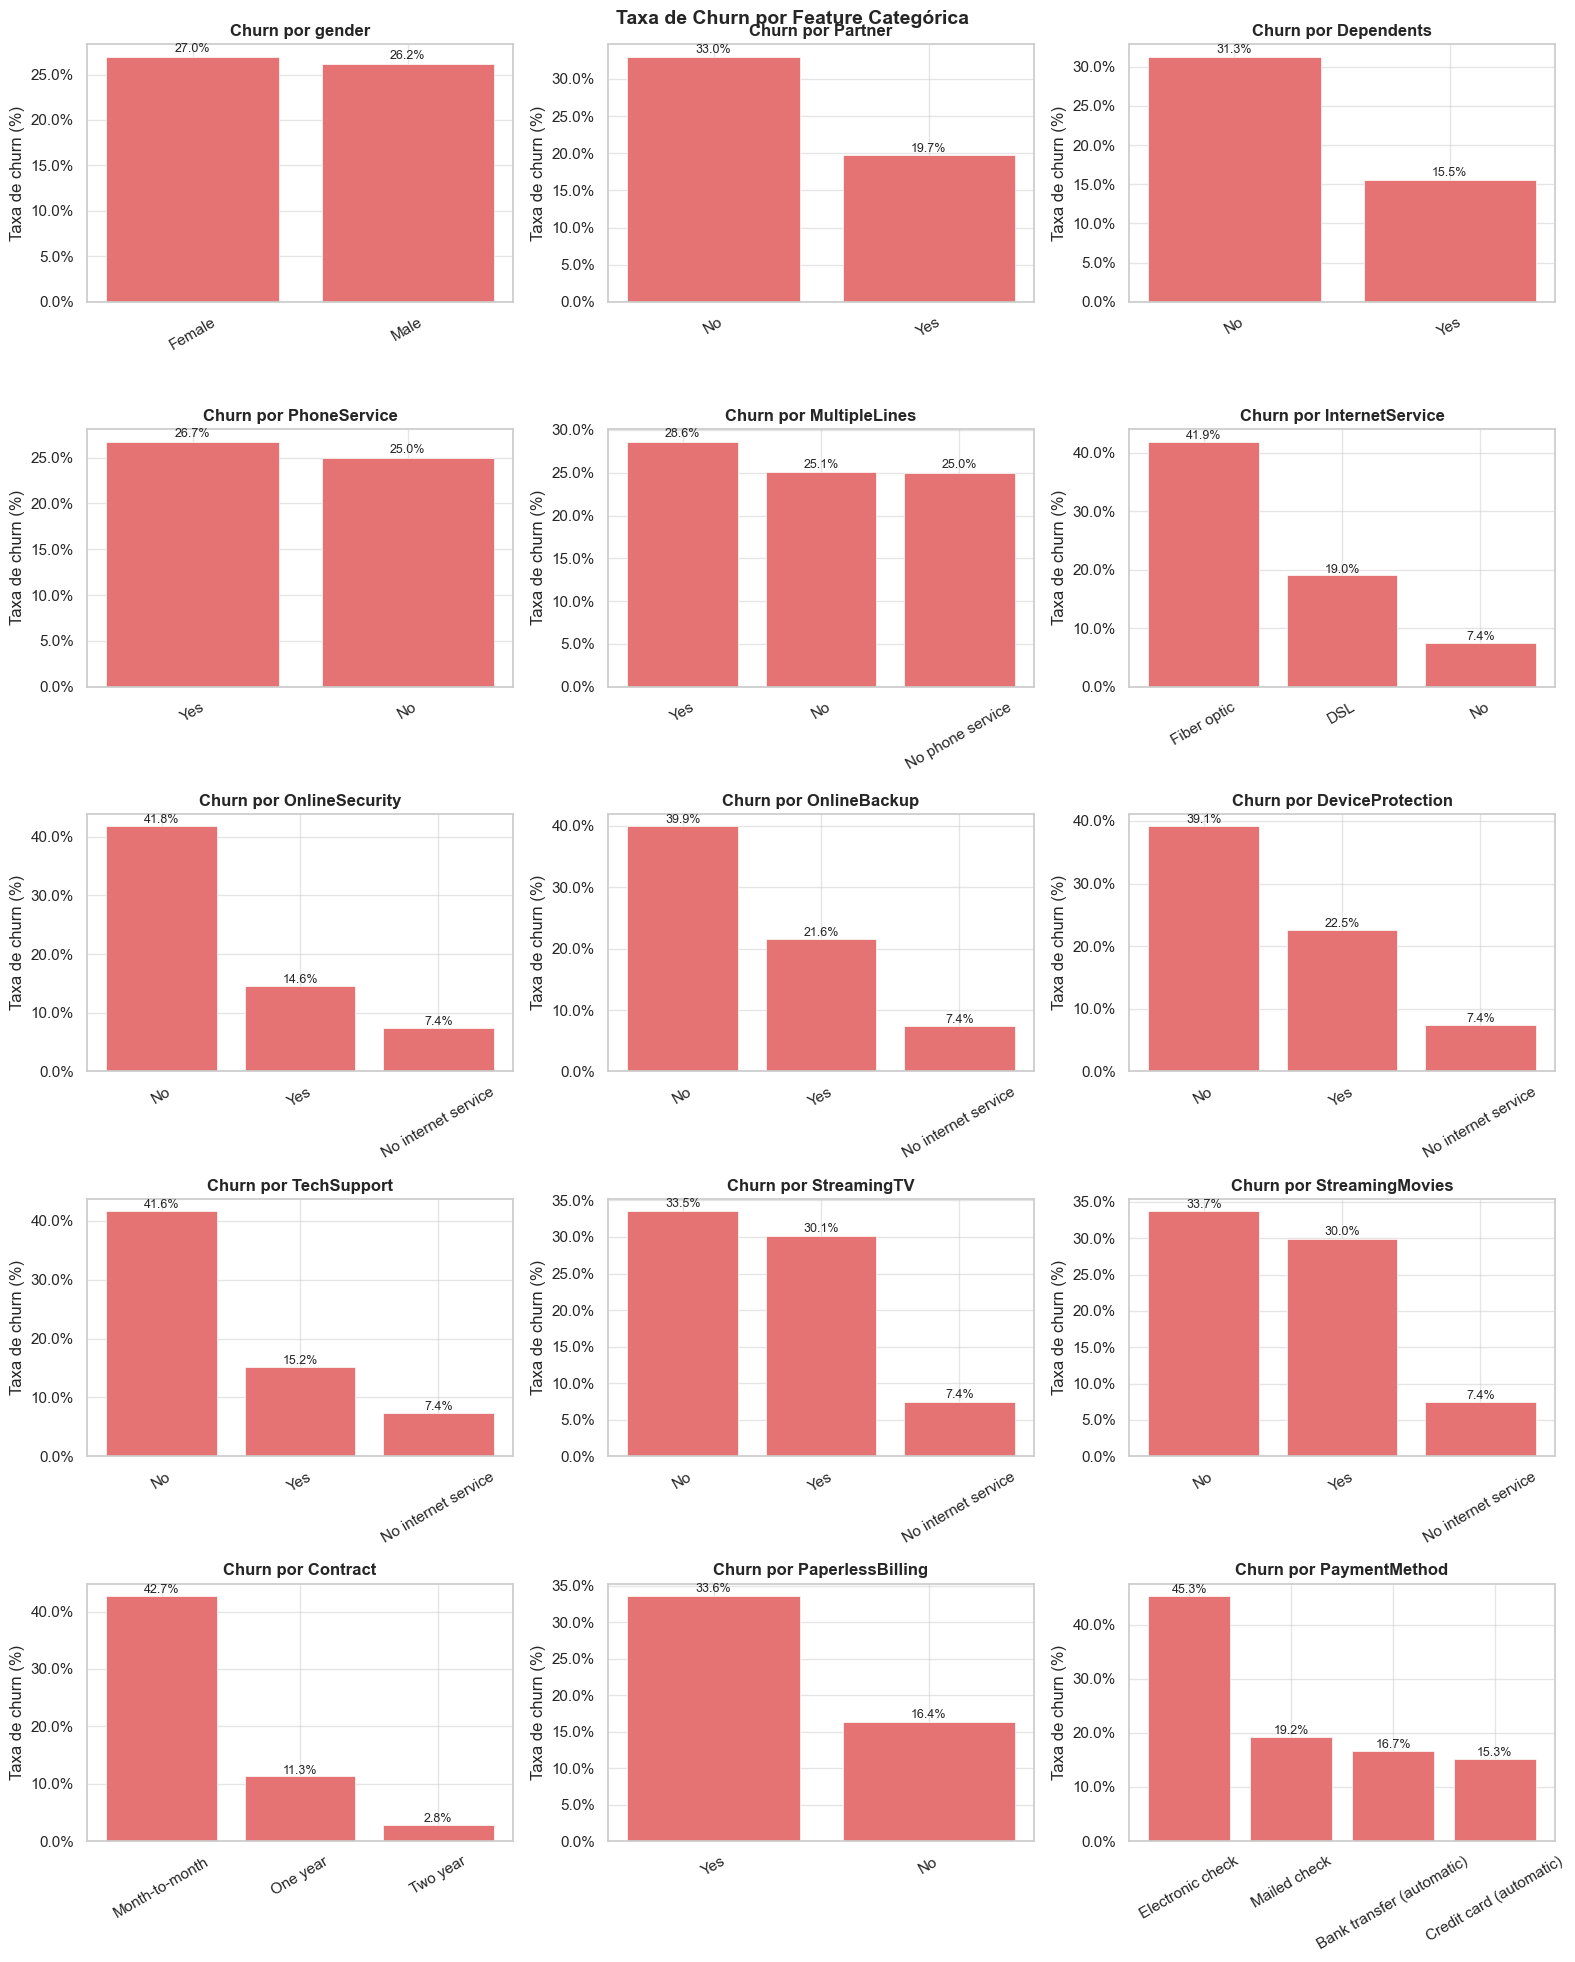

In [11]:
# ── Taxa de churn por feature categórica ──────────────────────────────────────
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate_by_cat = (
        df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=False)
    )
    bars = axes[i].bar(churn_rate_by_cat.index, churn_rate_by_cat.values,
                       color='#E57373', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'Churn por {col}', fontweight='bold')
    axes[i].set_ylabel('Taxa de churn (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, churn_rate_by_cat.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9)

# Remove subplots vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Taxa de Churn por Feature Categórica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/eda_categorical_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Análise de correlações

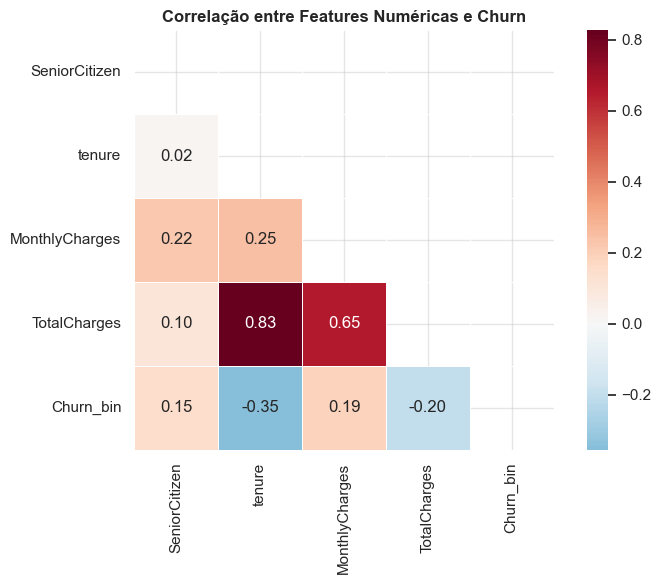


Correlação com Churn:
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn_bin, dtype: float64


In [12]:
# ── Correlação entre features numéricas ───────────────────────────────────────
# Codifica o target para correlação
df_corr = df.copy()
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_cols = num_cols + ['Churn_bin']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Correlação entre Features Numéricas e Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('docs/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelação com Churn:')
print(corr_matrix['Churn_bin'].drop('Churn_bin').sort_values(ascending=False))

## 7. Data Readiness

In [13]:
# ── Avaliação de Data Readiness ───────────────────────────────────────────────
readiness = {
    'Volume': {
        'valor': f'{len(df):,} registros',
        'status': '✅ Suficiente (mín. 5.000)',
        'ok': len(df) >= 5000
    },
    'Features': {
        'valor': f'{df.shape[1] - 2} features preditivas',
        'status': '✅ Suficiente (mín. 10)',
        'ok': df.shape[1] >= 10
    },
    'Valores ausentes': {
        'valor': f'{df.isnull().sum().sum()} valores',
        'status': '✅ Resolvido após limpeza',
        'ok': True
    },
    'Duplicatas': {
        'valor': f'{df.duplicated().sum()} linhas',
        'status': '✅ Sem duplicatas',
        'ok': df.duplicated().sum() == 0
    },
    'Desbalanceamento': {
        'valor': f'{churn_rate:.1f}% churn',
        'status': '⚠️  Requer SMOTE ou class_weight',
        'ok': False
    },
    'Tipo do target': {
        'valor': 'Binário (Yes/No)',
        'status': '✅ Classificação binária',
        'ok': True
    },
}

print('=' * 60)
print('RELATÓRIO DE DATA READINESS')
print('=' * 60)
for criterio, info in readiness.items():
    print(f'{criterio:<25} {info["valor"]:<25} {info["status"]}')
print('=' * 60)

score = sum(1 for v in readiness.values() if v['ok'])
total = len(readiness)
print(f'\nScore de Readiness: {score}/{total}')
print('→ Dataset pronto para modelagem com tratamento de desbalanceamento')

RELATÓRIO DE DATA READINESS
Volume                    7,032 registros           ✅ Suficiente (mín. 5.000)
Features                  19 features preditivas    ✅ Suficiente (mín. 10)
Valores ausentes          0 valores                 ✅ Resolvido após limpeza
Duplicatas                0 linhas                  ✅ Sem duplicatas
Desbalanceamento          26.6% churn               ⚠️  Requer SMOTE ou class_weight
Tipo do target            Binário (Yes/No)          ✅ Classificação binária

Score de Readiness: 5/6
→ Dataset pronto para modelagem com tratamento de desbalanceamento


## 8. Definição de métricas

In [14]:
print('''
╔══════════════════════════════════════════════════════════════╗
║           DEFINIÇÃO DE MÉTRICAS — CHURN PREDICTION           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  MÉTRICAS TÉCNICAS                                           ║
║  ─────────────────                                           ║
║  Primária:   PR-AUC (Precision-Recall AUC)                   ║
║              → Mais adequada para dataset desbalanceado      ║
║                                                              ║
║  Secundária: AUC-ROC                                         ║
║              → Comparação entre modelos                      ║
║                                                              ║
║  Terciária:  F1-Score (macro)                                ║
║              → Equilíbrio entre precisão e recall            ║
║                                                              ║
║  Quaternária: Recall da classe positiva (Churn=Yes)          ║
║              → Minimizar falsos negativos (custo alto)       ║
║                                                              ║
║  ANÁLISE DE CUSTO (trade-off)                                ║
║  ────────────────────────────                                ║
║  Falso Negativo (FN): Cliente churn não detectado            ║
║  → CUSTO ALTO: perde o cliente sem intervenção              ║
║                                                              ║
║  Falso Positivo (FP): Cliente não-churn classificado churn   ║
║  → CUSTO BAIXO: gasta com retenção desnecessária             ║
║                                                              ║
║  CONCLUSÃO: Priorizar Recall alto (minimizar FN)             ║
║                                                              ║
║  MÉTRICA DE NEGÓCIO                                          ║
║  ──────────────────                                          ║
║  Custo de churn evitado por período                          ║
║  → (TP × valor médio do cliente) - (FP × custo retenção)    ║
║                                                              ║
║  SLOs (Service Level Objectives)                             ║
║  ─────────────────────────────                               ║
║  PR-AUC  ≥ 0.60                                              ║
║  AUC-ROC ≥ 0.75                                              ║
║  Recall  ≥ 0.70                                              ║
║  Latência API ≤ 200ms (p95)                                  ║
╚══════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════╗
║           DEFINIÇÃO DE MÉTRICAS — CHURN PREDICTION           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  MÉTRICAS TÉCNICAS                                           ║
║  ─────────────────                                           ║
║  Primária:   PR-AUC (Precision-Recall AUC)                   ║
║              → Mais adequada para dataset desbalanceado      ║
║                                                              ║
║  Secundária: AUC-ROC                                         ║
║              → Comparação entre modelos                      ║
║                                                              ║
║  Terciária:  F1-Score (macro)                                ║
║              → Equilíbrio entre precisão e recall            ║
║                                                              ║
║  Quaternária: Recall d

## 9. Registro no MLflow

In [15]:
# ── Registra metadados do EDA no MLflow ───────────────────────────────────────
mlflow.set_tracking_uri(settings.mlflow_tracking_uri)
mlflow.set_experiment(settings.mlflow_experiment_name)

with mlflow.start_run(run_name='eda_exploratorio'):
    # Parâmetros do dataset
    mlflow.log_params({
        'dataset': 'Telco Customer Churn (IBM)',
        'n_registros': len(df),
        'n_features': df.shape[1] - 2,
        'n_features_numericas': len(num_cols),
        'n_features_categoricas': len(cat_cols),
        'seed': settings.seed,
        'versao_dataset': 'v1.0',
    })

    # Métricas do dataset
    mlflow.log_metrics({
        'churn_rate': round(churn_rate / 100, 4),
        'n_churn': int((df['Churn'] == 'Yes').sum()),
        'n_nao_churn': int((df['Churn'] == 'No').sum()),
        'missing_values_total': int(df.isnull().sum().sum()),
        'duplicatas': int(df.duplicated().sum()),
        'data_readiness_score': score / total,
    })

    # Artefatos
    mlflow.log_artifact('docs/eda_churn_distribution.png')
    mlflow.log_artifact('docs/eda_numeric_features.png')
    mlflow.log_artifact('docs/eda_categorical_churn_rate.png')
    mlflow.log_artifact('docs/eda_correlation_matrix.png')

    run_id = mlflow.active_run().info.run_id
    logger.info(f'MLflow run registrado: {run_id}')
    print('✅ EDA registrado no MLflow!')
    print(f'   Run ID: {run_id}')
    print(f'   Acesse: {settings.mlflow_tracking_uri}')

2026-05-17 11:53:27 | INFO     | __main__:<module>:34 | MLflow run registrado: 479837bb053047258d90f033b7081d15
✅ EDA registrado no MLflow!
   Run ID: 479837bb053047258d90f033b7081d15
   Acesse: http://localhost:5001
🏃 View run eda_exploratorio at: http://localhost:5001/#/experiments/1/runs/479837bb053047258d90f033b7081d15
🧪 View experiment at: http://localhost:5001/#/experiments/1


## 10. Conclusões e próximos passos

In [16]:
print('''
╔══════════════════════════════════════════════════════════════╗
║                    CONCLUSÕES DO EDA                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ACHADOS PRINCIPAIS                                          ║
║  ─────────────────                                           ║
║  1. Dataset com 7.032 registros e 19 features preditivas     ║
║  2. Taxa de churn ~26% — desbalanceamento moderado           ║
║  3. TotalCharges tinha 11 registros inválidos (removidos)    ║
║  4. Sem duplicatas no dataset                                ║
║  5. Clientes com contrato Month-to-month têm churn maior     ║
║  6. Clientes com menor tenure (tempo) têm mais churn         ║
║  7. Fiber optic tem maior taxa de churn vs DSL               ║
║                                                              ║
║  DECISÕES DE PRÉ-PROCESSAMENTO                               ║
║  ──────────────────────────────                              ║
║  - Encoding: OneHotEncoder para categóricas                  ║
║  - Scaling: StandardScaler para numéricas                    ║
║  - Desbalanceamento: SMOTE + class_weight no PyTorch         ║
║  - Validação: StratifiedKFold (k=5)                          ║
║                                                              ║
║  PRÓXIMOS PASSOS (Etapa 1 — continuação)                     ║
║  ────────────────────────────────────────                    ║
║  → 02_baselines.ipynb: DummyClassifier + Regressão Logística ║
║  → 03_mlp_pytorch.ipynb: Rede neural MLP                     ║
╚══════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════╗
║                    CONCLUSÕES DO EDA                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ACHADOS PRINCIPAIS                                          ║
║  ─────────────────                                           ║
║  1. Dataset com 7.032 registros e 19 features preditivas     ║
║  2. Taxa de churn ~26% — desbalanceamento moderado           ║
║  3. TotalCharges tinha 11 registros inválidos (removidos)    ║
║  4. Sem duplicatas no dataset                                ║
║  5. Clientes com contrato Month-to-month têm churn maior     ║
║  6. Clientes com menor tenure (tempo) têm mais churn         ║
║  7. Fiber optic tem maior taxa de churn vs DSL               ║
║                                                              ║
║  DECISÕES DE PRÉ-PROCESSAMENTO                               ║
║  ─────────────────────